In [2]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from persiantools.jdatetime import JalaliDate
import jalali_pandas
import pandas_ta  as ta

In [3]:
df = pd.read_csv(r'../data/RMCI.csv', encoding='utf-8')
df.head()

,ticker,miladi,open,high,low,close,volume,value,transaction_count,lastday_price,shamsi
0,همراه,20130820,42000.0,42200.0,42000.0,42001.0,546520,2.295462e+10,69,1000.0,13920529
1,همراه,20130821,42009.0,43500.0,42005.0,42142.0,161499,6.929039e+09,214,42001.0,13920530
2,همراه,20130824,43300.0,43300.0,42222.0,42191.0,110913,4.724576e+09,168,42142.0,13920602
3,همراه,20130825,42860.0,42860.0,42453.0,42213.0,67490,2.869908e+09,94,42191.0,13920603
4,همراه,20130826,42401.0,42501.0,42036.0,42214.0,160307,6.768045e+09,121,42213.0,13920604


In [4]:
df['Gregorian_Date'] = pd.to_datetime(df['miladi'], format='%Y%m%d')
df["Jalali_Date"] = df["Gregorian_Date"].jalali.to_jalali()
df['year'] = df["Jalali_Date"].jalali.year
df['month'] = df["Jalali_Date"].jalali.month
df['day'] = df["Jalali_Date"].jalali.day
df['weekday'] = df["Jalali_Date"].jalali.weekday

df['close_diff'] = df['close'].diff()
df['close_diff_sign'] = df['close_diff'].apply(lambda x: 1 if x > 0 else 0)

df.drop(['ticker','shamsi','miladi'],axis=1,inplace=True)

In [5]:
df

,open,high,low,close,volume,value,transaction_count,lastday_price,Gregorian_Date,Jalali_Date,year,month,day,weekday,close_diff,close_diff_sign
0,42000.0,42200.0,42000.0,42001.0,546520,2.295462e+10,69,1000.0,2013-08-20,1392-05-29 00:00:00,1392,5,29,3,NaN,0
1,42009.0,43500.0,42005.0,42142.0,161499,6.929039e+09,214,42001.0,2013-08-21,1392-05-30 00:00:00,1392,5,30,4,141.0,1
2,43300.0,43300.0,42222.0,42191.0,110913,4.724576e+09,168,42142.0,2013-08-24,1392-06-02 00:00:00,1392,6,2,0,49.0,1
3,42860.0,42860.0,42453.0,42213.0,67490,2.869908e+09,94,42191.0,2013-08-25,1392-06-03 00:00:00,1392,6,3,1,22.0,1
4,42401.0,42501.0,42036.0,42214.0,160307,6.768045e+09,121,42213.0,2013-08-26,1392-06-04 00:00:00,1392,6,4,2,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2730,4640.0,4659.0,4482.0,4527.0,11027218,4.978342e+10,611,4536.0,2024-12-10,1403-09-20 00:00:00,1403,9,20,3,-9.0,0
2731,4526.0,4650.0,4476.0,4536.0,9501665,4.326700e+10,529,4527.0,2024-12-11,1403-09-21 00:00:00,1403,9,21,4,9.0,1
2732,4672.0,4672.0,4670.0,4596.0,11756783,5.492769e+10,310,4536.0,2024-12-14,1403-09-24 00:00:00,1403,9,24,0,60.0,1
2733,4733.0,4733.0,4608.0,4657.0,39000016,1.816105e+11,937,4596.0,2024-12-15,1403-09-25 00:00:00,1403,9,25,1,61.0,1


In [6]:
df['ema_5'] = df.ta.ema(5)
df['ema_10'] = df.ta.ema(10)
df['ema_20'] = df.ta.ema(20)
df['ema_40'] = df.ta.ema(40)
df['ema_60'] = df.ta.ema(60)

df['sma_5'] = df.ta.sma(5)
df['sma_10'] = df.ta.sma(10)
df['sma_20'] = df.ta.sma(20)
df['sma_40'] = df.ta.sma(40)
df['sma_60'] = df.ta.sma(60)

df['trima_5'] = df.ta.trima(5)
df['trima_10'] = df.ta.trima(10)
df['trima_20'] = df.ta.trima(20)
df['trima_40'] = df.ta.trima(40)
df['trima_60'] = df.ta.trima(60)

df['rsi_5'] = df.ta.rsi(5)
df['rsi_10'] = df.ta.rsi(10)
df['rsi_20'] = df.ta.rsi(20)
df['rsi_40'] = df.ta.rsi(40)
df['rsi_60'] = df.ta.rsi(60)

df['atr_5'] = df.ta.atr(length=5)
df['atr_10'] = df.ta.atr(length=10)
df['atr_20'] = df.ta.atr(length=20)
df['atr_40'] = df.ta.atr(length=40)
df['atr_60'] = df.ta.atr(length=60)

df['obv'] = df.ta.obv()
df['adx_5'] = df.ta.adx(length=5)['ADX_5']
df['adx_10'] = df.ta.adx(length=10)['ADX_10']
df['adx_20'] = df.ta.adx(length=20)['ADX_20']
df['adx_40'] = df.ta.adx(length=40)['ADX_40']
df['adx_60'] = df.ta.adx(length=60)['ADX_60']

macd = df.ta.macd(fast=12, slow=26, signal=9)
df = pd.concat([df, macd], axis=1)

bb = df.ta.bbands(length=20)  # Default window of 20
df = pd.concat([df, bb], axis=1)

stoch = df.ta.stoch(k=14, d=3)
df = pd.concat([df, stoch], axis=1)



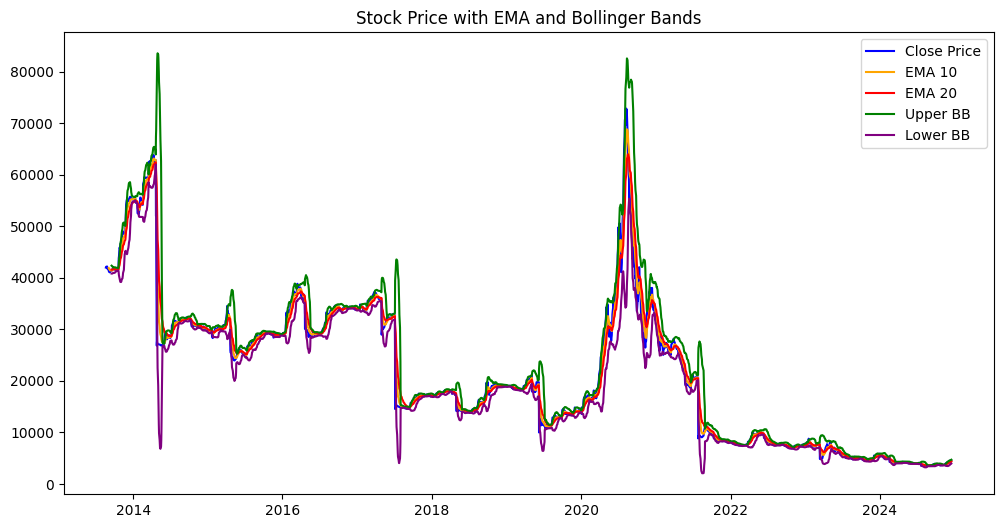

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['Gregorian_Date'], df['close'], label='Close Price', color='blue')
plt.plot(df['Gregorian_Date'], df['ema_10'], label='EMA 10', color='orange')
plt.plot(df['Gregorian_Date'], df['ema_20'], label='EMA 20', color='red')
plt.plot(df['Gregorian_Date'], df['BBU_20_2.0'], label='Upper BB', color='green')
plt.plot(df['Gregorian_Date'], df['BBL_20_2.0'], label='Lower BB', color='purple')
plt.title('Stock Price with EMA and Bollinger Bands')
plt.legend()
plt.show()

In [8]:
# 2-find the most realted features to fill the missing values
corr = df.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm')


,open,high,low,close,volume,value,transaction_count,lastday_price,year,month,day,weekday,close_diff,close_diff_sign,ema_5,ema_10,ema_20,ema_40,ema_60,sma_5,sma_10,sma_20,sma_40,sma_60,trima_5,trima_10,trima_20,trima_40,trima_60,rsi_5,rsi_10,rsi_20,rsi_40,rsi_60,atr_5,atr_10,atr_20,atr_40,atr_60,obv,adx_5,adx_10,adx_20,adx_40,adx_60,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,STOCHk_14_3_3,STOCHd_14_3_3
open,1.000000,0.998202,0.998179,0.929164,-0.230625,0.168133,0.057422,0.927031,-0.718843,0.071863,-0.006271,0.004822,0.077816,0.115031,0.924663,0.921084,0.913963,0.899532,0.884852,0.922855,0.918286,0.908908,0.887311,0.867233,0.922238,0.915781,0.907711,0.881996,0.857921,0.211834,0.286918,0.374046,0.477757,0.528822,0.065644,0.183214,0.290262,0.377639,0.426683,-0.561898,0.075845,0.142447,0.236019,0.375509,0.439149,0.209568,-0.000608,0.223010,0.903233,0.908908,0.871105,0.001566,0.192684,0.080415,0.098550
high,0.998202,1.000000,0.999370,0.927990,-0.227755,0.172443,0.064133,0.925846,-0.715373,0.074033,-0.006914,0.005848,0.082625,0.121032,0.923380,0.919880,0.912912,0.898715,0.884179,0.921541,0.917047,0.907951,0.886515,0.866698,0.920900,0.914552,0.906736,0.881237,0.857354,0.212012,0.286719,0.373854,0.477839,0.529188,0.060555,0.179236,0.287453,0.376277,0.426124,-0.558609,0.074242,0.141569,0.234680,0.372703,0.434955,0.207312,-0.001427,0.220854,0.902081,0.907951,0.870351,0.001978,0.193376,0.076852,0.094929
low,0.998179,0.999370,1.000000,0.927968,-0.233675,0.157647,0.045264,0.925808,-0.724151,0.074928,-0.007576,0.005163,0.081967,0.117831,0.923428,0.919995,0.913156,0.899197,0.884936,0.921590,0.917174,0.908204,0.886997,0.867452,0.920956,0.914683,0.906982,0.881740,0.858073,0.211474,0.286767,0.373760,0.476685,0.526897,0.057251,0.175418,0.283030,0.371381,0.421348,-0.565518,0.073840,0.141692,0.235332,0.373151,0.436249,0.205421,-0.001847,0.218987,0.904436,0.908204,0.868899,-0.004995,0.193149,0.077473,0.095717
close,0.929164,0.927990,0.927968,1.000000,-0.257984,0.143279,0.018129,0.997892,-0.747455,0.030322,0.000975,0.001480,0.029076,0.071849,0.997908,0.993924,0.985257,0.968092,0.951406,0.997043,0.991483,0.979199,0.954907,0.931381,0.996782,0.989184,0.977752,0.949260,0.921584,0.207486,0.287861,0.384930,0.504512,0.568192,0.309053,0.364922,0.422850,0.473128,0.505585,-0.587852,0.144138,0.192147,0.287942,0.441703,0.532031,0.248558,-0.000174,0.264364,0.969936,0.979199,0.941010,0.009507,0.177938,0.134524,0.137759
volume,-0.230625,-0.227755,-0.233675,-0.257984,1.000000,0.643748,0.562895,-0.260144,0.400083,-0.098811,-0.004946,0.015515,0.046982,0.130824,-0.262139,-0.265602,-0.271262,-0.280995,-0.290080,-0.262242,-0.265520,-0.270224,-0.279232,-0.286836,-0.262299,-0.265941,-0.269244,-0.277318,-0.284490,0.101798,0.076559,0.060033,0.050865,0.047039,-0.044318,-0.040169,-0.051879,-0.089984,-0.125231,0.484451,0.005513,-0.040137,-0.079220,-0.114366,-0.147492,0.059995,0.021802,0.056877,-0.296223,-0.270224,-0.236686,0.192792,0.073037,0.078301,0.069149
value,0.168133,0.172443,0.157647,0.143279,0.643748,1.000000,0.846370,0.137756,0.223183,-0.099189,-0.003234,0.026805,0.110743,0.161867,0.135078,0.127188,0.112299,0.085893,0.063054,0.134433,0.126610,0.110848,0.079706,0.053564,0.133870,0.124815,0.112413,0.079236,0.050526,0.142167,0.144096,0.161914,0.201478,0.234892,0.129521,0.189370,0.222065,0.209142,0.179202,0.229082,0.015730,-0.007197,-0.009352,0.039763,0.093628,0.262772,0.030042,0.269583,0.034764,0.110848,0.166958,0.270895,0.127788,0.114283,0.107454
transaction_count,0.057422,0.064133,0.045264,0.018129,0.562895,0.846370,1.000000,0.014458,0.327827,-0.115880,-0.004785,0.022372,0.093001,0.132010,0.010688,0.003287,-0.010022,-0.033106,-0.052405,0.010193,0.002916,-0.011071,-0.037275,-0.059113,0.009806,0.001437,-0.009739,-0.036784,-0.060558,0.110799,0.115610,0.135298,0.178459,0.217934,0.074279,0.129829,0.161248,0.151046,0.124561,0.274281,-0.001276,-0.023608,-0.016736,0.031664,0.072589,0.228829,0.034408,0.232255,-0.093699,-0.0110

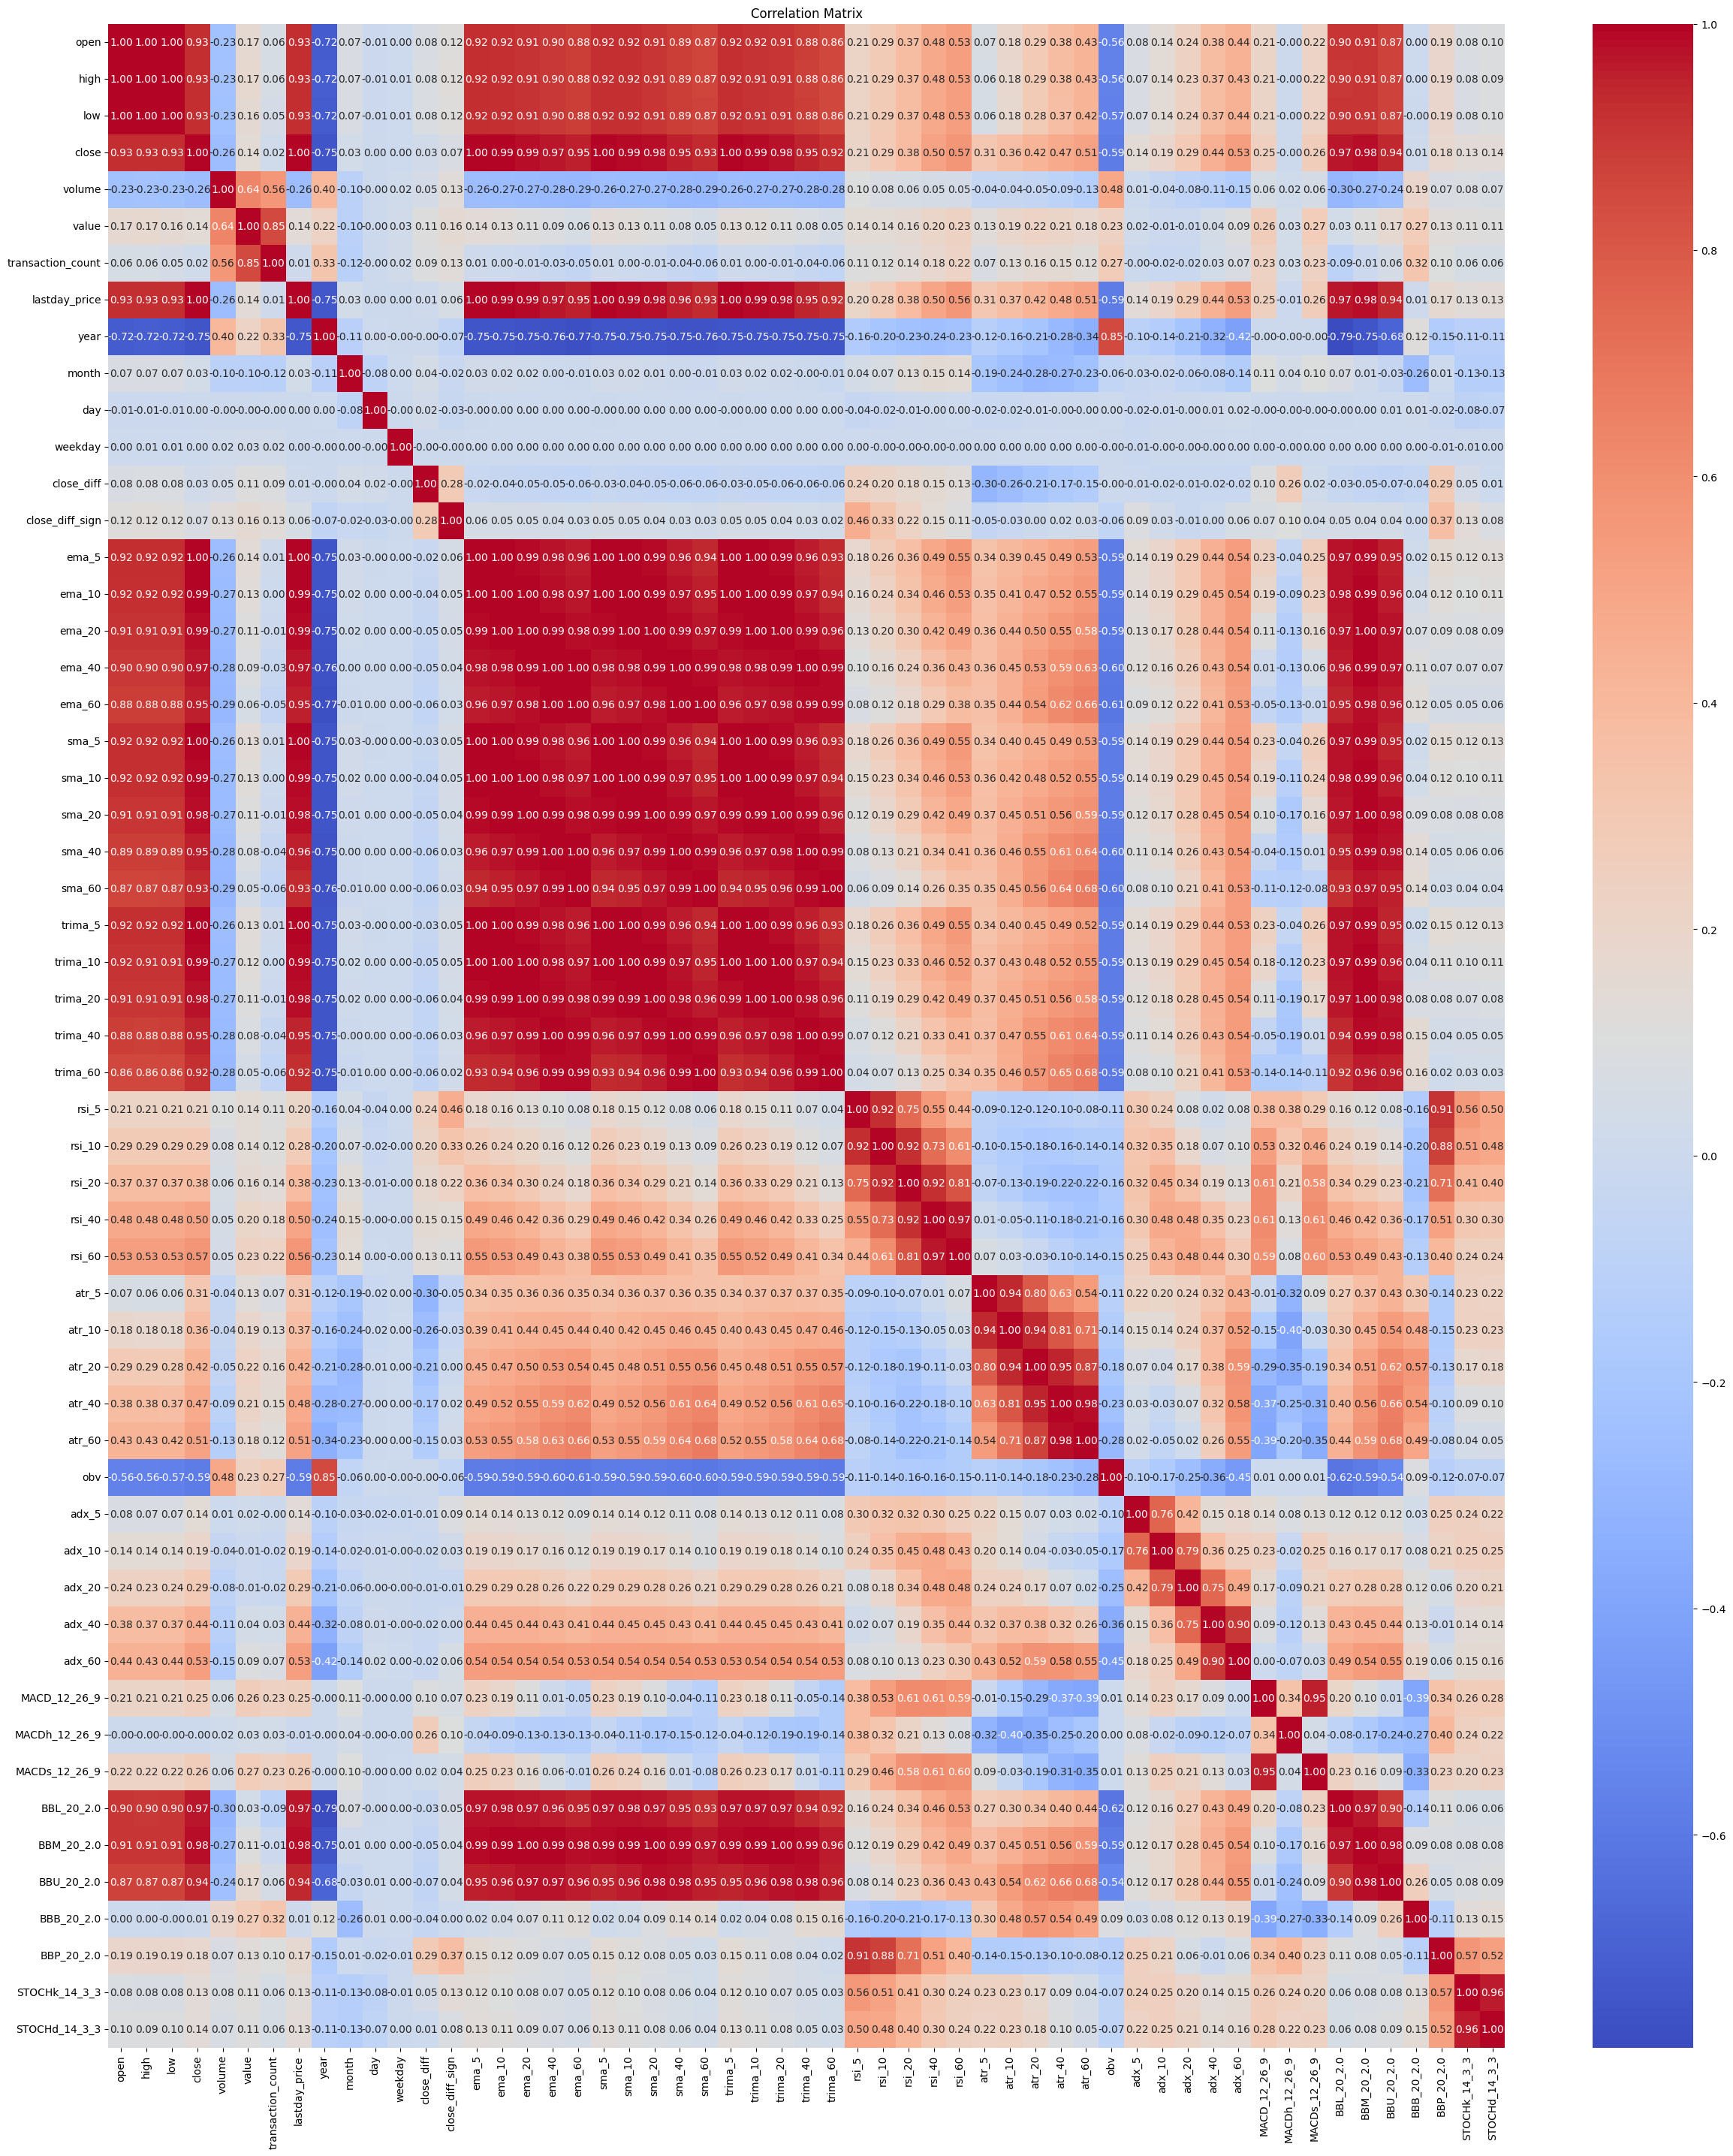

In [13]:
corr = df.corr(numeric_only=True)

# ذخیره‌ی ماتریس همبستگی به عنوان تصویر
plt.figure(figsize=(30, 35))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Correlation Matrix")
# plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

In [14]:
df.to_csv('MCI_indicator.csv',encoding='utf-8-sig',index=False)